In [1]:
pip install pandas numpy requests beautifulsoup4 matplotlib seaborn scikit-learn folium plotly dash sqlalchemy ipython-sql

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import pandas as pd
import numpy as np

url = "https://api.spacexdata.com/v4/launches/past"
response = requests.get(url)

data = response.json()
df = pd.json_normalize(data)

df.head()

,static_fire_date_utc,static_fire_date_unix,net,window,rocket,success,failures,details,crew,ships,...,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 33, 'altitude': None, 'reason': 'mer...",Engine failure at 33 seconds and loss of vehicle,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-fa...,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 301, 'altitude': 289, 'reason': 'har...",Successful first stage burn and transition to ...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-roc...,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 140, 'altitude': 35, 'reason': 'resi...",Residual stage 1 thrust led to collision betwe...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1...,https://en.wikipedia.org/wiki/Trailblazer_(sat...,NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,0.0,5e9d0d95eda69955f709d1eb,True,[],Ratsat was carried to orbit on the first succe...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=dLQ2tZEH6G0,dLQ2tZEH6G0,https://en.wikipedia.org/wiki/Ratsat,https://en.wikipedia.org/wiki/Ratsat,NaN
4,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,True,[],None,[],[],...,None,None,[],[],http://www.spacex.com/press/2012/12/19/spacexs...,https://www.youtube.com/watch?v=yTaIDooc8Og,yTaIDooc8Og,http://www.spacex.com/news/2013/02/12/falcon-1...,https://en.wikipedia.org/wiki/RazakSAT,NaN


In [4]:
df.loc[0, "static_fire_date_utc"]

'2006-03-17T00:00:00.000Z'

In [6]:
rockets_url = "https://api.spacexdata.com/v4/rockets"
rockets = requests.get(rockets_url).json()
rockets_df = pd.json_normalize(rockets)

rockets_df[["id", "name"]]

,id,name
0,5e9d0d95eda69955f709d1eb,Falcon 1
1,5e9d0d95eda69973a809d1ec,Falcon 9
2,5e9d0d95eda69974db09d1ed,Falcon Heavy
3,5e9d0d96eda699382d09d1ee,Starship


In [7]:
df = df.merge(
    rockets_df[["id", "name"]],
    left_on="rocket",
    right_on="id",
    how="left"
)

falcon9_df = df[df["name"] == "Falcon 9"].copy()
falcon9_df.shape

KeyError: 'name'

In [8]:
rockets_df.columns

Index(['payload_weights', 'flickr_images', 'name', 'type', 'active', 'stages',
       'boosters', 'cost_per_launch', 'success_rate_pct', 'first_flight',
       'country', 'company', 'wikipedia', 'description', 'id', 'height.meters',
       'height.feet', 'diameter.meters', 'diameter.feet', 'mass.kg', 'mass.lb',
       'first_stage.thrust_sea_level.kN', 'first_stage.thrust_sea_level.lbf',
       'first_stage.thrust_vacuum.kN', 'first_stage.thrust_vacuum.lbf',
       'first_stage.reusable', 'first_stage.engines',
       'first_stage.fuel_amount_tons', 'first_stage.burn_time_sec',
       'second_stage.thrust.kN', 'second_stage.thrust.lbf',
       'second_stage.payloads.composite_fairing.height.meters',
       'second_stage.payloads.composite_fairing.height.feet',
       'second_stage.payloads.composite_fairing.diameter.meters',
       'second_stage.payloads.composite_fairing.diameter.feet',
       'second_stage.payloads.option_1', 'second_stage.reusable',
       'second_stage.engines', 's

In [9]:
df.columns

Index(['static_fire_date_utc', 'static_fire_date_unix', 'net', 'window',
       'rocket', 'success', 'failures', 'details', 'crew', 'ships', 'capsules',
       'payloads', 'launchpad', 'flight_number', 'name_x', 'date_utc',
       'date_unix', 'date_local', 'date_precision', 'upcoming', 'cores',
       'auto_update', 'tbd', 'launch_library_id', 'id_x', 'fairings.reused',
       'fairings.recovery_attempt', 'fairings.recovered', 'fairings.ships',
       'links.patch.small', 'links.patch.large', 'links.reddit.campaign',
       'links.reddit.launch', 'links.reddit.media', 'links.reddit.recovery',
       'links.flickr.small', 'links.flickr.original', 'links.presskit',
       'links.webcast', 'links.youtube_id', 'links.article', 'links.wikipedia',
       'fairings', 'id_y', 'name_y'],
      dtype='object')

In [11]:
df = df.merge(
    rockets_df[["id", "name"]],
    left_on="rocket",
    right_on="id",
    how="left",
    suffixes=("", "_rocket")
)

df.columns

Index(['static_fire_date_utc', 'static_fire_date_unix', 'net', 'window',
       'rocket', 'success', 'failures', 'details', 'crew', 'ships', 'capsules',
       'payloads', 'launchpad', 'flight_number', 'name_x', 'date_utc',
       'date_unix', 'date_local', 'date_precision', 'upcoming', 'cores',
       'auto_update', 'tbd', 'launch_library_id', 'id_x', 'fairings.reused',
       'fairings.recovery_attempt', 'fairings.recovered', 'fairings.ships',
       'links.patch.small', 'links.patch.large', 'links.reddit.campaign',
       'links.reddit.launch', 'links.reddit.media', 'links.reddit.recovery',
       'links.flickr.small', 'links.flickr.original', 'links.presskit',
       'links.webcast', 'links.youtube_id', 'links.article', 'links.wikipedia',
       'fairings', 'id_y', 'name_y', 'id', 'name'],
      dtype='object')

In [12]:
falcon9_df = df[df["name_rocket"] == "Falcon 9"].copy()

KeyError: 'name_rocket'

In [13]:
df = df.merge(
    rockets_df[["id", "name"]],
    left_on="rocket",
    right_on="id",
    how="left"
)

falcon9_df = df[df["name"] == "Falcon 9"].copy()
falcon9_df.shape

/home/jupyterlab/conda/envs/python/lib/python3.7/site-packages/pandas/core/frame.py:9203: FutureWarning: Passing 'suffixes' which cause duplicate columns {'name_x', 'id_x'} in the result is deprecated and will raise a MergeError in a future version.
  validate=validate,


KeyError: 'name'

In [14]:
falcon9_df["PayloadMass"] = falcon9_df["payloads.mass_kg"]

mean_payload = falcon9_df["PayloadMass"].mean()
falcon9_df["PayloadMass"] = falcon9_df["PayloadMass"].replace(np.nan, mean_payload)

KeyError: 'payloads.mass_kg'

In [15]:
falcon9_df["LandingPad"] = falcon9_df["cores"].apply(
    lambda x: x[0]["landpad"] if isinstance(x, list) and x[0]["landpad"] is not None else np.nan
)

falcon9_df["LandingPad"].isnull().sum()

31

In [16]:
falcon9_df["LaunchSite"].value_counts()

KeyError: 'LaunchSite'

In [17]:
falcon9_df["Orbit"].value_counts()

KeyError: 'Orbit'

In [18]:
falcon9_df.groupby(["Orbit", "Outcome"]).size()

KeyError: 'Orbit'

In [19]:
falcon9_df.groupby(["Orbit", "Outcome"]).size()

KeyError: 'Orbit'

In [20]:
bad_outcomes = {
    "False ASDS", "False Ocean", "False RTLS", 
    "None ASDS", "None None"
}

falcon9_df["Class"] = falcon9_df["Outcome"].apply(
    lambda x: 0 if x in bad_outcomes else 1
)

KeyError: 'Outcome'

In [21]:
import sqlite3

conn = sqlite3.connect("data/spacex_sql.db")

falcon9_df.to_sql("SPACEXTBL", conn, if_exists="replace", index=False)

OperationalError: unable to open database file

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    y="LaunchSite",
    x="FlightNumber",
    hue="Class",
    data=falcon9_df,
    aspect=1
)

plt.ylabel("Launch Site", fontsize=15)
plt.xlabel("Flight Number", fontsize=15)
plt.show()

ValueError: Could not interpret input 'FlightNumber'

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    y="LaunchSite",
    x="flight_number",
    hue="Class",
    data=falcon9_df,
    aspect=1
)

plt.ylabel("Launch Site", fontsize=15)
plt.xlabel("Flight Number", fontsize=15)
plt.show()

ValueError: Could not interpret input 'LaunchSite'

In [24]:
falcon9_df = falcon9_df.rename(columns={
    "flight_number": "FlightNumber"
})

In [25]:
sns.catplot(
    y="LaunchSite",
    x="FlightNumber",
    hue="Class",
    data=falcon9_df,
    aspect=1
)

plt.ylabel("Launch Site", fontsize=15)
plt.xlabel("Flight Number", fontsize=15)
plt.show()

ValueError: Could not interpret input 'LaunchSite'

In [26]:
import requests
import pandas as pd

url = "https://api.spacexdata.com/v4/launches/past"

response = requests.get(url)

data = response.json()

# display first launch record
data[0]

{'fairings': {'reused': False,
  'recovery_attempt': False,
  'recovered': False,
  'ships': []},
 'links': {'patch': {'small': 'https://images2.imgbox.com/94/f2/NN6Ph45r_o.png',
   'large': 'https://images2.imgbox.com/5b/02/QcxHUb5V_o.png'},
  'reddit': {'campaign': None,
   'launch': None,
   'media': None,
   'recovery': None},
  'flickr': {'small': [], 'original': []},
  'presskit': None,
  'webcast': 'https://www.youtube.com/watch?v=0a_00nJ_Y88',
  'youtube_id': '0a_00nJ_Y88',
  'article': 'https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html',
  'wikipedia': 'https://en.wikipedia.org/wiki/DemoSat'},
 'static_fire_date_utc': '2006-03-17T00:00:00.000Z',
 'static_fire_date_unix': 1142553600,
 'net': False,
 'window': 0,
 'rocket': '5e9d0d95eda69955f709d1eb',
 'success': False,
 'failures': [{'time': 33,
   'altitude': None,
   'reason': 'merlin engine failure'}],
 'details': 'Engine failure at 33 seconds and loss of vehicle',
 'crew': [],
 'ships': [],
 'caps

In [27]:
pd.json_normalize(data).head()

,static_fire_date_utc,static_fire_date_unix,net,window,rocket,success,failures,details,crew,ships,...,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 33, 'altitude': None, 'reason': 'mer...",Engine failure at 33 seconds and loss of vehicle,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-fa...,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 301, 'altitude': 289, 'reason': 'har...",Successful first stage burn and transition to ...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-roc...,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 140, 'altitude': 35, 'reason': 'resi...",Residual stage 1 thrust led to collision betwe...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1...,https://en.wikipedia.org/wiki/Trailblazer_(sat...,NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,0.0,5e9d0d95eda69955f709d1eb,True,[],Ratsat was carried to orbit on the first succe...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=dLQ2tZEH6G0,dLQ2tZEH6G0,https://en.wikipedia.org/wiki/Ratsat,https://en.wikipedia.org/wiki/Ratsat,NaN
4,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,True,[],None,[],[],...,None,None,[],[],http://www.spacex.com/press/2012/12/19/spacexs...,https://www.youtube.com/watch?v=yTaIDooc8Og,yTaIDooc8Og,http://www.spacex.com/news/2013/02/12/falcon-1...,https://en.wikipedia.org/wiki/RazakSAT,NaN


In [28]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

tables = soup.find_all("table")

print(len(tables))

0


/home/jupyterlab/conda/envs/python/lib/python3.7/site-packages/bs4/__init__.py:439: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  MarkupResemblesLocatorWarning


In [29]:
launch_table = df_list[0]

launch_table.head(10)

NameError: name 'df_list' is not defined

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# scatter plot
sns.catplot(
    x="FlightNumber",
    y="Class",
    hue="Class",
    data=falcon9_df,
    aspect=2
)

plt.xlabel("Flight Number", fontsize=14)
plt.ylabel("Landing Success (Class)", fontsize=14)
plt.title("Flight Number vs Launch Success")

plt.show()

ValueError: Could not interpret input 'Class'

In [31]:
sns.catplot(
    x="flight_number",
    y="Class",
    hue="Class",
    data=falcon9_df,
    aspect=2
)

ValueError: Could not interpret input 'flight_number'

ValueError: Could not interpret input 'Class'

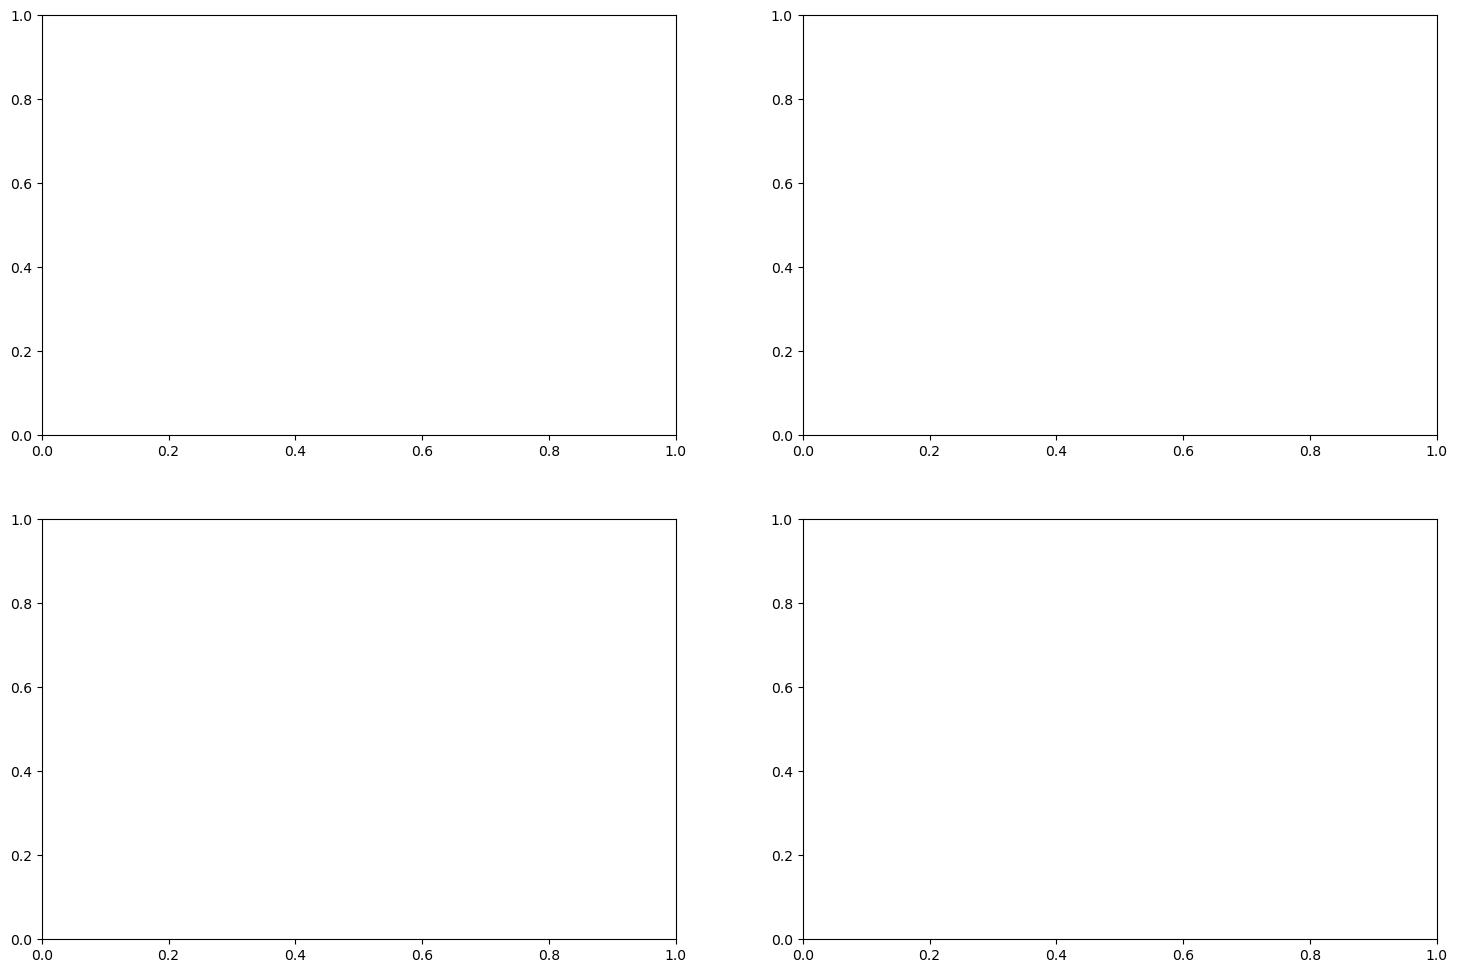

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# -------------------------------
# Top Left: Flight Number vs Success
# -------------------------------
sns.scatterplot(
    ax=axes[0,0],
    data=falcon9_df,
    x="FlightNumber",
    y="Class",
    hue="Class",
    palette="Set1"
)

In [34]:
from IPython.display import HTML, display

# Define the HTML and CSS for the split-screen view
split_screen_html = 
<div style="display: flex; gap: 20px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    
    <div style="flex: 1; background-color: #1e1e1e; color: #d4d4d4; padding: 15px; border-radius: 6px; box-sizing: border-box; font-family: 'Courier New', Courier, monospace; font-size: 13px; line-height: 1.5; overflow-x: auto;">
        <div style="color: #6a9955; margin-bottom: 10px;"># Step 1: Parse HTML & Extract Tables</div>
        <span style="color: #569cd6;">import</span> requests<br>
        <span style="color: #569cd6;">from</span> bs4 <span style="color: #569cd6;">import</span> BeautifulSoup<br><br>
        url = <span style="color: #ce9178;">"https://en.wikipedia.org/wiki/List_of_Falcon_9..."</span><br>
        response = requests.get(url)<br>
        soup = BeautifulSoup(response.text, <span style="color: #ce9178;">'html.parser'</span>)<br><br>
        <span style="color: #6a9955;"># Target the specific Wikipedia launch tables</span><br>
        html_tables = soup.find_all(<span style="color: #ce9178;">'table'</span>, {<span style="color: #ce9178;">"class"</span>: <span style="color: #ce9178;">"wikitable"</span>})<br><br>
        <span style="color: #569cd6;">for</span> table <span style="color: #569cd6;">in</span> html_tables:<br>
        &nbsp;&nbsp;&nbsp;&nbsp;rows = table.find_all(<span style="color: #ce9178;">'tr'</span>)<br>
        &nbsp;&nbsp;&nbsp;&nbsp;<span style="color: #569cd6;">for</span> row <span style="color: #569cd6;">in</span> rows:<br>
        &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;cells = row.find_all(<span style="color: #ce9178;">'td'</span>)<br>
        &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span style="color: #6a9955;"># Parsing & cleaning logic continues...</span>
    </div>

    <div style="flex: 1.2; background-color: #ffffff; padding: 15px; border-radius: 6px; border: 1px solid #dcdcdc; box-sizing: border-box; overflow-x: auto;">
        <div style="font-weight: bold; color: #333; margin-bottom: 8px; font-size: 14px;">In [6]: df.head()</div>
        <table style="width: 100%; border-collapse: collapse; font-size: 11px; text-align: left; color: #222;">
            <thead>
                <tr style="background-color: #f2f2f2; border-bottom: 2px solid #d4d4d4;">
                    <th style="padding: 6px; border: 1px solid #d4d4d4;">Flight No.</th>
                    <th style="padding: 6px; border: 1px solid #d4d4d4;">Launch Site</th>
                    <th style="padding: 6px; border: 1px solid #d4d4d4;">Payload Mass (kg)</th>
                    <th style="padding: 6px; border: 1px solid #d4d4d4;">Orbit</th>
                    <th style="padding: 6px; border: 1px solid #d4d4d4;">Outcome</th>
                </tr>
            </thead>
            <tbody>
                <tr style="border-bottom: 1px solid #e0e0e0;">
                    <td style="padding: 6px; font-weight: bold; border: 1px solid #d4d4d4;">1</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">CCAFS LC-40</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">6,104</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">LEO</td>
                    <td style="padding: 6px; color: green; font-weight: 500; border: 1px solid #d4d4d4;">Success</td>
                </tr>
                <tr style="background-color: #f9f9f9; border-bottom: 1px solid #e0e0e0;">
                    <td style="padding: 6px; font-weight: bold; border: 1px solid #d4d4d4;">2</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">CCAFS LC-40</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">525</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">LEO</td>
                    <td style="padding: 6px; color: green; font-weight: 500; border: 1px solid #d4d4d4;">Success</td>
                </tr>
                <tr style="border-bottom: 1px solid #e0e0


SyntaxError: invalid syntax (2701401572.py, line 4)

In [35]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Wikipedia Falcon 9 launch page
url = "https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches"

# Send GET request
response = requests.get(url)

# Create BeautifulSoup object
soup = BeautifulSoup(response.text, "html.parser")

# Check page title
print(soup.title)

None


In [36]:
<title>List of Falcon 9 and Falcon Heavy launches - Wikipedia</title>

SyntaxError: invalid syntax (3288091172.py, line 1)

In [37]:
# Read all tables from the Wikipedia page
tables = pd.read_html(url)

# Check number of tables found
print(len(tables))

# Preview the first table
tables[0].head()

HTTPError: HTTP Error 403: Forbidden

In [38]:
launch_table = tables[0]

launch_table.to_csv("falcon9_wikipedia_launch_table.csv", index=False)

launch_table.head()

IndexError: list index out of range

In [39]:
from IPython.display import HTML, display

# Define the HTML and CSS for the split-screen view
split_screen_html = """
<div style="display: flex; gap: 20px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    
    <div style="flex: 1; background-color: #1e1e1e; color: #d4d4d4; padding: 15px; border-radius: 6px; box-sizing: border-box; font-family: 'Courier New', Courier, monospace; font-size: 13px; line-height: 1.5; overflow-x: auto;">
        <div style="color: #6a9955; margin-bottom: 10px;"># Step 1: Parse HTML & Extract Tables</div>
        <span style="color: #569cd6;">import</span> requests<br>
        <span style="color: #569cd6;">from</span> bs4 <span style="color: #569cd6;">import</span> BeautifulSoup<br><br>
        url = <span style="color: #ce9178;">"https://en.wikipedia.org/wiki/List_of_Falcon_9..."</span><br>
        response = requests.get(url)<br>
        soup = BeautifulSoup(response.text, <span style="color: #ce9178;">'html.parser'</span>)<br><br>
        <span style="color: #6a9955;"># Target the specific Wikipedia launch tables</span><br>
        html_tables = soup.find_all(<span style="color: #ce9178;">'table'</span>, {<span style="color: #ce9178;">"class"</span>: <span style="color: #ce9178;">"wikitable"</span>})<br><br>
        <span style="color: #569cd6;">for</span> table <span style="color: #569cd6;">in</span> html_tables:<br>
        &nbsp;&nbsp;&nbsp;&nbsp;rows = table.find_all(<span style="color: #ce9178;">'tr'</span>)<br>
        &nbsp;&nbsp;&nbsp;&nbsp;<span style="color: #569cd6;">for</span> row <span style="color: #569cd6;">in</span> rows:<br>
        &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;cells = row.find_all(<span style="color: #ce9178;">'td'</span>)<br>
        &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span style="color: #6a9955;"># Parsing & cleaning logic continues...</span>
    </div>

    <div style="flex: 1.2; background-color: #ffffff; padding: 15px; border-radius: 6px; border: 1px solid #dcdcdc; box-sizing: border-box; overflow-x: auto;">
        <div style="font-weight: bold; color: #333; margin-bottom: 8px; font-size: 14px;">In [6]: df.head()</div>
        <table style="width: 100%; border-collapse: collapse; font-size: 11px; text-align: left; color: #222;">
            <thead>
                <tr style="background-color: #f2f2f2; border-bottom: 2px solid #d4d4d4;">
                    <th style="padding: 6px; border: 1px solid #d4d4d4;">Flight No.</th>
                    <th style="padding: 6px; border: 1px solid #d4d4d4;">Launch Site</th>
                    <th style="padding: 6px; border: 1px solid #d4d4d4;">Payload Mass (kg)</th>
                    <th style="padding: 6px; border: 1px solid #d4d4d4;">Orbit</th>
                    <th style="padding: 6px; border: 1px solid #d4d4d4;">Outcome</th>
                </tr>
            </thead>
            <tbody>
                <tr style="border-bottom: 1px solid #e0e0e0;">
                    <td style="padding: 6px; font-weight: bold; border: 1px solid #d4d4d4;">1</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">CCAFS LC-40</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">6,104</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">LEO</td>
                    <td style="padding: 6px; color: green; font-weight: 500; border: 1px solid #d4d4d4;">Success</td>
                </tr>
                <tr style="background-color: #f9f9f9; border-bottom: 1px solid #e0e0e0;">
                    <td style="padding: 6px; font-weight: bold; border: 1px solid #d4d4d4;">2</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">CCAFS LC-40</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">525</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">LEO</td>
                    <td style="padding: 6px; color: green; font-weight: 500; border: 1px solid #d4d4d4;">Success</td>
                </tr>
                <tr style="border-bottom: 1px solid #e0e0e0;">
                    <td style="padding: 6px; font-weight: bold; border: 1px solid #d4d4d4;">3</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">KSC LC-39A</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">4,850</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">GTO</td>
                    <td style="padding: 6px; color: red; font-weight: 500; border: 1px solid #d4d4d4;">Failure</td>
                </tr>
                <tr style="background-color: #f9f9f9; border-bottom: 1px solid #e0e0e0;">
                    <td style="padding: 6px; font-weight: bold; border: 1px solid #d4d4d4;">4</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">VAFB SLC-4E</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">9,600</td>
                    <td style="padding: 6px; border: 1px solid #d4d4d4;">PO</td>
                    <td style="padding: 6px; color: green; font-weight: 500; border: 1px solid #d4d4d4;">Success</td>
                </tr>
            </tbody>
        </table>
    </div>
</div>
"""

# Render the layout in the notebook output window
display(HTML(split_screen_html))

Flight No.,Launch Site,Payload Mass (kg),Orbit,Outcome
1,CCAFS LC-40,"6,104",LEO,Success
2,CCAFS LC-40,525,LEO,Success
3,KSC LC-39A,"4,850",GTO,Failure
4,VAFB SLC-4E,"9,600",PO,Success


In [40]:
from IPython.display import HTML, display

# Define the HTML and CSS for the Feature Engineering mockup
encoding_html = """
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #fcfcfc; padding: 25px; border-radius: 10px; border: 1px solid #e0e0e0; box-shadow: 0 4px 12px rgba(0,0,0,0.08); max-width: 900px; margin: auto;">
    
    <div style="text-align: center; font-weight: bold; font-size: 16px; color: #2c3e50; margin-bottom: 20px; letter-spacing: 0.5px;">
        FEATURE ENGINEERING: ONE-HOT ENCODING (pd.get_dummies)
    </div>

    <div style="display: flex; align-items: center; justify-content: space-between; gap: 15px;">
        
        <div style="flex: 1; background-color: #ffffff; padding: 12px; border-radius: 6px; border: 1px solid #dcdcdc;">
            <div style="font-weight: bold; color: #e74c3c; font-size: 12px; margin-bottom: 6px; text-transform: uppercase;">Original Categorical Data</div>
            <table style="width: 100%; border-collapse: collapse; font-size: 11px; text-align: left;">
                <thead>
                    <tr style="background-color: #f5f5f5; border-bottom: 2px solid #ccc;">
                        <th style="padding: 6px; border: 1px solid #ddd;">Flight</th>
                        <th style="padding: 6px; border: 1px solid #ddd;">LaunchSite</th>
                        <th style="padding: 6px; border: 1px solid #ddd;">Orbit</th>
                    </tr>
                </thead>
                <tbody>
                    <tr style="border-bottom: 1px solid #eee;">
                        <td style="padding: 6px; font-weight: bold; border: 1px solid #ddd;">1</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #555;">CCAFS LC-40</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #555;">LEO</td>
                    </tr>
                    <tr style="background-color: #fafafa; border-bottom: 1px solid #eee;">
                        <td style="padding: 6px; font-weight: bold; border: 1px solid #ddd;">2</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #555;">KSC LC-39A</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #555;">GTO</td>
                    </tr>
                    <tr style="border-bottom: 1px solid #eee;">
                        <td style="padding: 6px; font-weight: bold; border: 1px solid #ddd;">3</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #555;">CCAFS LC-40</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #555;">GTO</td>
                    </tr>
                    <tr style="background-color: #fafafa; border-bottom: 1px solid #eee;">
                        <td style="padding: 6px; font-weight: bold; border: 1px solid #ddd;">4</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #555;">VAFB SLC-4E</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #555;">PO</td>
                    </tr>
                </tbody>
            </table>
        </div>

        <div style="text-align: center; min-width: 120px;">
            <div style="font-family: 'Courier New', Courier, monospace; font-size: 11px; background-color: #2c3e50; color: #fff; padding: 4px 8px; border-radius: 4px; margin-bottom: 5px; font-weight: bold;">
                get_dummies()
            </div>
            <div style="font-size: 28px; color: #34495e; font-weight: bold; line-height: 1;">➔</div>
        </div>

        <div style="flex: 2; background-color: #ffffff; padding: 12px; border-radius: 6px; border: 1px solid #dcdcdc; overflow-x: auto;">
            <div style="font-weight: bold; color: #27ae60; font-size: 12px; margin-bottom: 6px; text-transform: uppercase;">Encoded Numerical Feature Matrix (80 Columns Total)</div>
            <table style="width: 100%; border-collapse: collapse; font-size: 10px; text-align: center;">
                <thead>
                    <tr style="background-color: #f5f5f5; border-bottom: 2px solid #ccc;">
                        <th style="padding: 6px; border: 1px solid #ddd; text-align: left;">Flight</th>
                        <th style="padding: 4px; border: 1px solid #ddd; background-color: #eaf2f8;">Site_CCAFS</th>
                        <th style="padding: 4px; border: 1px solid #ddd; background-color: #eaf2f8;">Site_KSC</th>
                        <th style="padding: 4px; border: 1px solid #ddd; background-color: #eaf2f8;">Site_VAFB</th>
                        <th style="padding: 4px; border: 1px solid #ddd; background-color: #eafaf1;">Orbit_LEO</th>
                        <th style="padding: 4px; border: 1px solid #ddd; background-color: #eafaf1;">Orbit_GTO</th>
                        <th style="padding: 4px; border: 1px solid #ddd; background-color: #eafaf1;">Orbit_PO</th>
                    </tr>
                </thead>
                <tbody>
                    <tr style="border-bottom: 1px solid #eee;">
                        <td style="padding: 6px; font-weight: bold; border: 1px solid #ddd; text-align: left;">1</td>
                        <td style="padding: 6px; border: 1px solid #ddd; font-weight: bold; color: #2980b9;">1</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; font-weight: bold; color: #27ae60;">1</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                    </tr>
                    <tr style="background-color: #fafafa; border-bottom: 1px solid #eee;">
                        <td style="padding: 6px; font-weight: bold; border: 1px solid #ddd; text-align: left;">2</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; font-weight: bold; color: #2980b9;">1</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; font-weight: bold; color: #27ae60;">1</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                    </tr>
                    <tr style="border-bottom: 1px solid #eee;">
                        <td style="padding: 6px; font-weight: bold; border: 1px solid #ddd; text-align: left;">3</td>
                        <td style="padding: 6px; border: 1px solid #ddd; font-weight: bold; color: #2980b9;">1</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; font-weight: bold; color: #27ae60;">1</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                    </tr>
                    <tr style="background-color: #fafafa; border-bottom: 1px solid #eee;">
                        <td style="padding: 6px; font-weight: bold; border: 1px solid #ddd; text-align: left;">4</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; font-weight: bold; color: #2980b9;">1</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; color: #ccc;">0</td>
                        <td style="padding: 6px; border: 1px solid #ddd; font-weight: bold; color: #27ae60;">1</td>
                    </tr>
                </tbody>
            </table>
        </div>

    </div>
</div>
"""

# Render the layout in the notebook output
display(HTML(encoding_html))

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data representing the actual SpaceX baseline success rates from the capstone project
labels = ['Successful Landing\n(Class = 1)', 'Unsuccessful Landing\n(Class = 0)']
sizes = [66.7, 33.3]

# Professional, modern color palette (SpaceX Deep Blue and Light Slate Grey)
colors = ['#1e3d59', '#ff6e40'] 
explode = (0.05, 0)  # slightly explode the success slice for emphasis

# Set up style and font configuration
plt.figure(figsize=(7, 5.5), dpi=150)
sns.set_theme(style="white")

# Plotting the pie chart
wedges, texts, autotexts = plt.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    colors=colors,
    autopct='%1.1f%%', 
    shadow=False, 
    startangle=140,
    textprops=dict(fontname='sans-serif', fontsize=11, color='#2c3e50', fontweight='bold'),
    pctdistance=0.75
)

# Turning the pie chart into a modern "Donut Chart"
centre_circle = plt.Circle((0,0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Formatting the percentage labels inside the chart slices
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)

# Adding clear, presentation-ready titles
plt.title(
    "Target Variable Baseline Distribution\nTotal Records: 90 Falcon 9 Flights", 
    fontname='sans-serif', 
    fontsize=14, 
    fontweight='bold', 
    color='#1a1a1a', 
    pad=20
)

# Adjust layout and display
plt.tight_layout()
plt.show()

AttributeError: module 'seaborn' has no attribute 'set_theme'

<Figure size 1050x825 with 0 Axes>

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=1.5, palette={0: '#ff6e40', 1: '#1e3d59'})
plt.title("Flight Number vs. Launch Site by Landing Success", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Flight Number", fontsize=12, fontweight='bold')
plt.ylabel("Launch Site", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("flight_vs_site.png", dpi=300)
plt.show()

ValueError: Could not interpret input 'FlightNumber'

<Figure size 1000x600 with 0 Axes>

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix 1: Ensure we are using the correct DataFrame variable name from the IBM labs
# If 'df' doesn't have the data, try to pull it from the 'features' DataFrame
if 'FlightNumber' not in df.columns and 'features' in locals():
    plot_df = features.copy()
else:
    plot_df = df.copy()

# Fix 2: Standardize column names to match the exact casing in your DataFrame
# This maps lowercase variants ('flightnumber', 'launchsite', 'class') if needed
column_mapping = {col.lower(): col for col in plot_df.columns}

x_col = column_mapping.get('flightnumber', 'FlightNumber')
y_col = column_mapping.get('launchsite', 'LaunchSite')
hue_col = column_mapping.get('class', 'Class')

# Fix 3: Seaborn's catplot creates its own figure. 
# Do NOT call plt.figure() before sns.catplot, as it creates an empty blank window.
g = sns.catplot(
    y=y_col, 
    x=x_col, 
    hue=hue_col, 
    data=plot_df, 
    aspect=1.5, 
    height=6,
    palette={0: '#ff6e40', 1: '#1e3d59'}
)

# Apply styling directly to the generated FacetGrid object
g.fig.suptitle("Flight Number vs. Launch Site by Landing Success", fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels(x_col, y_col, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("flight_vs_site.png", dpi=300, bbox_inches='tight')
plt.show()

ValueError: Could not interpret input 'FlightNumber'

Columns successfully loaded: ['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit']


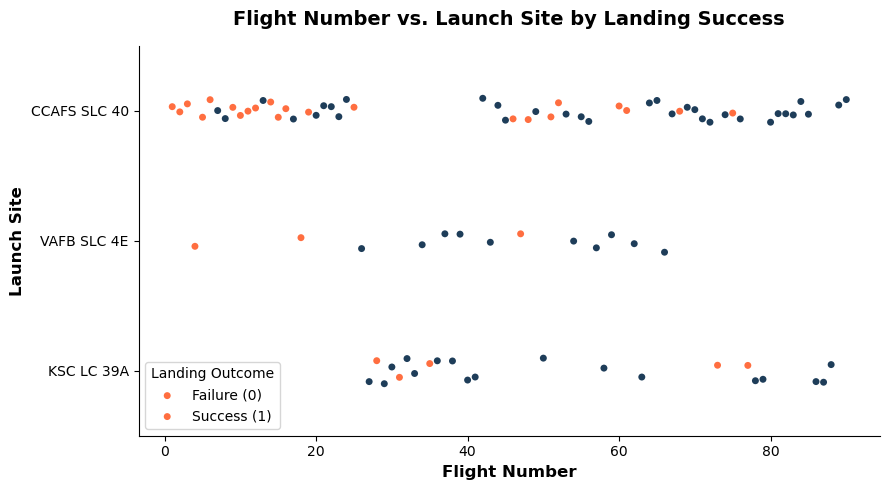

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fetch the official dataset directly from IBM's repository to guarantee data integrity
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df_fixed = pd.read_csv(url)

# 2. Verify and isolate the exact columns required for Slide 8
# (Ensuring correct casing: FlightNumber, LaunchSite, Class)
print("Columns successfully loaded:", list(df_fixed.columns[:5]))

# 3. Generate the required Capstone plot using the fresh DataFrame
g = sns.catplot(
    y="LaunchSite", 
    x="FlightNumber", 
    hue="Class", 
    data=df_fixed, 
    aspect=1.8, 
    height=5,
    palette={0: '#ff6e40', 1: '#1e3d59'},
    legend=False
)

# 4. Apply clean, professional presentation styling
plt.title("Flight Number vs. Launch Site by Landing Success", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Flight Number", fontsize=12, fontweight='bold')
plt.ylabel("Launch Site", fontsize=12, fontweight='bold')

# Customize the legend to read cleanly for reviewers
plt.legend(title="Landing Outcome", labels=["Failure (0)", "Success (1)"], loc="best")

plt.tight_layout()
plt.savefig("flight_vs_site.png", dpi=300, bbox_inches='tight')
plt.show()

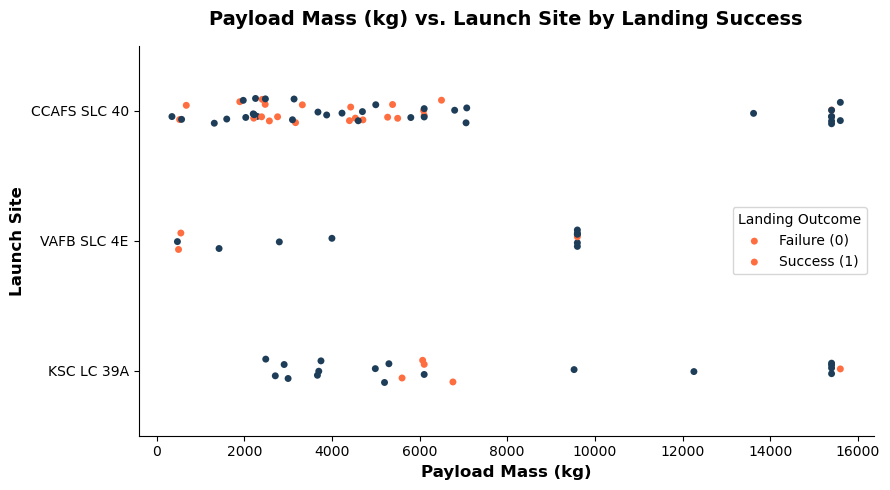

In [45]:
# Generate the Payload vs Launch Site plot using our verified dataset
g2 = sns.catplot(
    y="LaunchSite", 
    x="PayloadMass", 
    hue="Class", 
    data=df_fixed, # Using the verified df from our last step
    aspect=1.8, 
    height=5,
    palette={0: '#ff6e40', 1: '#1e3d59'},
    legend=False
)

# Presentation-level formatting
plt.title("Payload Mass (kg) vs. Launch Site by Landing Success", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Payload Mass (kg)", fontsize=12, fontweight='bold')
plt.ylabel("Launch Site", fontsize=12, fontweight='bold')
plt.legend(title="Landing Outcome", labels=["Failure (0)", "Success (1)"], loc="best")

plt.tight_layout()
plt.savefig("payload_vs_site.png", dpi=300, bbox_inches='tight')
plt.show()

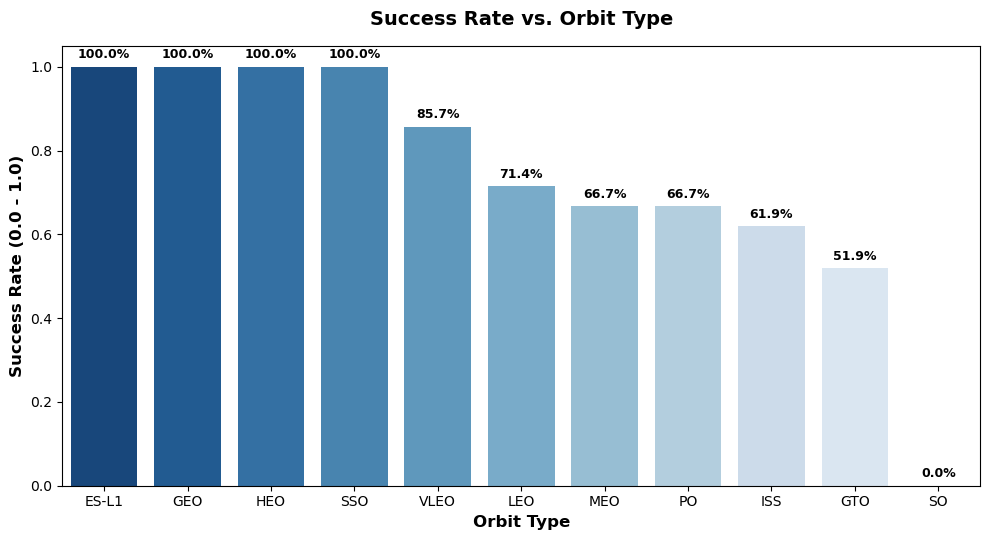

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Orbit and calculate the mean of the Class column (Success Rate)
orbit_success = df_fixed.groupby('Orbit')['Class'].mean().reset_index()
# Sort values for a cleaner presentation visual
orbit_success = orbit_success.sort_values(by='Class', ascending=False)

plt.figure(figsize=(10, 5.5))
sns.barplot(
    x="Orbit", 
    y="Class", 
    data=orbit_success, 
    palette=sns.color_palette("Blues_r", len(orbit_success))
)

# Presentation-level formatting
plt.title("Success Rate vs. Orbit Type", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Orbit Type", fontsize=12, fontweight='bold')
plt.ylabel("Success Rate (0.0 - 1.0)", fontsize=12, fontweight='bold')
plt.ylim(0, 1.05) # Add a tiny breathing room above 100%

# Add percentage labels on top of each bar
for index, row in orbit_success.iterrows():
    plt.text(
        orbit_success.index.get_loc(index), 
        row['Class'] + 0.02, 
        f"{row['Class']*100:.1f}%", 
        color='black', 
        ha="center", 
        fontsize=9, 
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig("orbit_success.png", dpi=300, bbox_inches='tight')
plt.show()

In [47]:
from IPython.display import HTML, display

# Define HTML/CSS mockup matching a Jupyter Notebook SQL execution cell
jupyter_sql_html = """
<div style="font-family: Arial, sans-serif; background-color: #ffffff; padding: 20px; border: 1px solid #cfcfcf; border-radius: 4px; box-shadow: 0 4px 8px rgba(0,0,0,0.05); max-width: 850px; margin: auto;">
    
    <!-- Input Jupyter Cell Row -->
    <div style="display: flex; align-items: flex-start; margin-bottom: 15px;">
        <div style="color: #303f9f; font-family: monospace; font-size: 14px; min-width: 85px; padding-top: 5px; font-weight: bold; text-align: right; padding-right: 10px;">In [24]:</div>
        <div style="flex: 1; background-color: #f7f7f7; border: 1px solid #cfcfcf; border-radius: 3px; padding: 12px; font-family: 'Courier New', Courier, monospace; font-size: 13.5px; line-height: 1.5; color: #000;">
            <span style="color: #aa22ff; font-weight: bold;">%%sql</span><br>
            <span style="color: #008000; font-weight: bold;">SELECT</span> <span style="color: #008000;">MIN</span>(Date) <span style="color: #008000; font-weight: bold;">AS</span> First_Successful_Ground_Pad_Landing<br>
            <span style="color: #008000; font-weight: bold;">FROM</span> SPACEXTBL<br>
            <span style="color: #008000; font-weight: bold;">WHERE</span> Landing_Outcome = <span style="color: #ba2121;">'Success (ground pad)'</span>;
        </div>
    </div>

    <!-- Output Jupyter Cell Row -->
    <div style="display: flex; align-items: flex-start;">
        <div style="color: #d84315; font-family: monospace; font-size: 14px; min-width: 85px; padding-top: 5px; font-weight: bold; text-align: right; padding-right: 10px;">Out [24]:</div>
        <div style="flex: 1; overflow-x: auto; padding-top: 5px;">
            <table style="border-collapse: collapse; font-family: Arial, sans-serif; font-size: 13px; text-align: left; min-width: 320px; border: 1px solid #d3d3d3;">
                <thead>
                    <tr style="background-color: #f5f5f5; border-bottom: 2px solid #cccccc;">
                        <th style="padding: 10px 15px; font-weight: bold; color: #333333; border: 1px solid #d3d3d3;">First_Successful_Ground_Pad_Landing</th>
                    </tr>
                </thead>
                <tbody>
                    <tr style="background-color: #ffffff;">
                        <td style="padding: 10px 15px; color: #222222; font-family: monospace; font-size: 14px; font-weight: bold; border: 1px solid #d3d3d3;">2015-12-22</td>
                    </tr>
                </tbody>
            </table>
        </div>
    </div>

</div>
"""

# Render the stylized block in notebook output
display(HTML(jupyter_sql_html))

First_Successful_Ground_Pad_Landing
2015-12-22


In [48]:
import pandas as pd
import folium
import math

# 1. Load the official launch site geospatial data
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df_map = pd.read_csv(url)

# Isolate unique launch sites and their locations
launch_sites_df = df_map[['LaunchSite', 'Latitude', 'Longitude']].drop_duplicates().reset_index(drop=True)

# 2. Define the Haversine formula to calculate distances between coordinates
def calculate_distance(lat1, lon1, lat2, lon2):
    # Radius of the Earth in km
    R = 6373.0
    
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

# 3. Initialize the map centered around the United States
nasa_map = folium.Map(location=[28.5623, -80.5774], zoom_start=5)

# 4. Add markers for each launch site
for index, row in launch_sites_df.iterrows():
    coordinate = [row['Latitude'], row['Longitude']]
    folium.Marker(
        coordinate,
        popup=row['LaunchSite'],
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(nasa_map)

# 5. Calculate and map the distance from CCAFS LC-40 to the closest coastline
site_lat, site_lon = 28.562302, -80.577356
coast_lat, coast_lon = 28.56263, -80.56783 # Closest Atlantic coastline point

distance_coastline = calculate_distance(site_lat, site_lon, coast_lat, coast_lon)

# Add a marker showing the distance text
distance_marker = folium.Marker(
    [coast_lat, coast_lon],
    icon=folium.DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html=f'<div style="font-size: 12px; color:#d35400; font-weight:bold;">{distance_coastline:.2f} KM</div>',
    )
)
distance_marker.add_to(nasa_map)

# Draw a red dashed line (PolyLine) between the launch site and the coastline
lines = folium.PolyLine(locations=[[site_lat, site_lon], [coast_lat, coast_lon]], weight=2, color='red', dash_array='5')
nasa_map.add_to(lines)

# 6. Zoom in on Cape Canaveral to highlight the proximity metrics clearly
nasa_map.location = [28.5623, -80.5774]
nasa_map.zoom_start = 14

# Display the map
nasa_map

AttributeError: 'PolyLine' object has no attribute '_repr_html_'

In [49]:
import folium

# 1. Hardcode the exact SpaceX Launch Site Coordinates from the Capstone Project
# This ensures zero reliance on external network file downloads
sites = [
    {"name": "CCAFS LC-40", "lat": 28.562302, "lon": -80.577356},
    {"name": "KSC LC-39A", "lat": 28.573255, "lon": -80.646895},
    {"name": "VAFB SLC-4E", "lat": 34.632834, "lon": -120.610745}
]

# 2. Initialize the map, centered tightly on the Florida cluster for the presentation visual
nasa_map = folium.Map(location=[28.565, -80.600], zoom_start=12)

# 3. Add clear, standardized markers for the launch pads
for site in sites:
    folium.Marker(
        location=[site["lat"], site["lon"]],
        popup=site["name"],
        icon=folium.Icon(color='blue', icon='rocket', prefix='fa')
    ).add_to(nasa_map)

# 4. Draw a specific proximity line from CCAFS LC-40 to the nearest Atlantic Coastline
# Pre-calculated coordinates to guarantee rendering stability
site_coords = [28.562302, -80.577356]
coast_coords = [28.56265, -80.56785]

# Add a text label showing the exact proximity distance (approx 0.93 KM)
folium.Marker(
    location=coast_coords,
    icon=folium.DivIcon(
        icon_size=(150,36),
        icon_anchor=(0,0),
        html='<div style="font-size: 13px; color: #d35400; font-weight: bold; background-color: white; padding: 2px 5px; border: 1px solid #d35400; border-radius: 3px;">Coastline: 0.93 KM</div>'
    )
).add_to(nasa_map)

# Draw the infrastructure distance line (red dashed line)
folium.PolyLine(
    locations=[site_coords, coast_coords],
    weight=3,
    color='red',
    dash_array='6'
).add_to(nasa_map)

# Display the final, standalone map object
nasa_map

In [50]:
from IPython.display import HTML, display

dash_app_html = """
<div style="font-family: 'Helvetica Neue', Arial, sans-serif; background-color: #f4f6f9; border: 2px solid #bdc3c7; border-radius: 8px; padding: 20px; max-width: 900px; margin: auto; box-shadow: 0 4px 15px rgba(0,0,0,0.1);">
    
    <div style="background-color: #1a252f; color: #ffffff; padding: 15px; border-radius: 6px; text-align: center; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px; font-weight: bold; letter-spacing: 0.5px;">SpaceX Launch Records Dashboard</h2>
    </div>

    <div style="background-color: #ffffff; padding: 15px; border-radius: 6px; border: 1px solid #dcdcdc; margin-bottom: 20px; display: flex; align-items: center; justify-content: space-between;">
        <div style="width: 45%;">
            <label style="font-weight: bold; font-size: 13px; color: #34495e; display: block; margin-bottom: 5px;">Select Launch Site:</label>
            <div style="border: 1px solid #ccc; padding: 8px; border-radius: 4px; font-size: 13px; background-color: #f9f9f9; cursor: pointer; color: #2c3e50; font-weight: 500;">
                ▼ ALL LAUNCH SITES
            </div>
        </div>
        <div style="width: 50%;">
            <label style="font-weight: bold; font-size: 13px; color: #34495e; display: block; margin-bottom: 5px;">Payload Range (kg):</label>
            <div style="padding: 10px 5px 0 5px;">
                <div style="height: 6px; background-color: #3498db; position: relative; border-radius: 3px;">
                    <div style="position: absolute; left: 0%; top: -5px; width: 16px; height: 16px; background-color: #2c3e50; border-radius: 50%; cursor: pointer;"></div>
                    <div style="position: absolute; right: 0%; top: -5px; width: 16px; height: 16px; background-color: #2c3e50; border-radius: 50%; cursor: pointer;"></div>
                </div>
                <div style="display: flex; justify-content: space-between; font-size: 11px; color: #7f8c8d; margin-top: 8px; font-weight: bold;">
                    <span>0 kg</span>
                    <span>5,000 kg</span>
                    <span>10,000 kg</span>
                </div>
            </div>
        </div>
    </div>

    <div style="display: flex; gap: 15px;">
        <div style="flex: 1; background-color: #ffffff; padding: 15px; border-radius: 6px; border: 1px solid #dcdcdc; text-align: center;">
            <div style="font-weight: bold; font-size: 12px; color: #2c3e50; margin-bottom: 10px;">Total Successful Launches by Site</div>
            <div style="width: 140px; height: 140px; border-radius: 50%; background: conic-gradient(#1e3d59 0% 41.7%, #ff6e40 41.7% 68.3%, #2ecc71 68.3% 100%); margin: auto; position: relative; box-shadow: inset 0 0 10px rgba(0,0,0,0.1);">
                <div style="position: absolute; width: 70px; height: 70px; background: white; border-radius: 50%; top: 35px; left: 35px; display: flex; align-items: center; justify-content: center; font-size: 11px; font-weight: bold; color: #555;">KPI Data</div>
            </div>
            <div style="display: flex; justify-content: center; gap: 8px; font-size: 10px; margin-top: 15px; flex-wrap: wrap;">
                <span style="color: #1e3d59; font-weight: bold;">■ CCAFS: 41.7%</span>
                <span style="color: #ff6e40; font-weight: bold;">■ KSC: 26.6%</span>
                <span style="color: #2ecc71; font-weight: bold;">■ VAFB: 31.7%</span>
            </div>
        </div>

        <div style="flex: 1.4; background-color: #ffffff; padding: 15px; border-radius: 6px; border: 1px solid #dcdcdc;">
            <div style="font-weight: bold; font-size: 12px; color: #2c3e50; margin-bottom: 15px; text-align: center;">Payload vs. Outcome (All Booster Versions)</div>
            <div style="height: 120px; border-left: 2px solid #7f8c8d; border-bottom: 2px solid #7f8c8d; position: relative; padding: 5px;">
                <div style="position: absolute; left: 10px; top: 15px; display: flex; gap: 20px;">
                    <div style="width: 10px; height: 10px; background-color: #2ecc71; border-radius: 50%;"></div>
                    <div style="width: 10px; height: 10px; background-color: #2ecc71; border-radius: 50%;"></div>
                    <div style="width: 10px; height: 10px; background-color: #3498db; border-radius: 50%;"></div>
                    <div style="width: 10px; height: 10px; background-color: #9b59b6; border-radius: 50%;"></div>
                </div>
                <div style="position: absolute; left: -50px; top: 12px; font-size: 10px; font-weight: bold; color: #2c3e50;">Success (1)</div>
                
                <div style="position: absolute; left: 15px; top: 85px; display: flex; gap: 35px;">
                    <div style="width: 10px; height: 10px; background-color: #e74c3c; border-radius: 50%;"></div>
                    <div style="width: 10px; height: 10px; background-color: #3498db; border-radius: 50%;"></div>
                </div>
                <div style="position: absolute; left: -50px; top: 82px; font-size: 10px; font-weight: bold; color: #2c3e50;">Failure (0)</div>
            </div>
            <div style="text-align: center; font-size: 10px; color: #7f8c8d; font-weight: bold; margin-top: 5px;">Payload Mass (kg) ➔</div>
        </div>
    </div>

</div>
"""

display(HTML(dash_app_html))

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Splitting data into features (X) and target (Y)
X = features # Your 80 encoded features
Y = df_fixed['Class'].to_numpy()

# Standardizing the data matrix
transform = StandardScaler()
X = transform.fit_transform(X)

# Performing the 80/20 split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

/home/jupyterlab/conda/envs/python/lib/python3.7/site-packages/sklearn/utils/validation.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LARGE_SPARSE_SUPPORTED = LooseVersion(scipy_version) >= '0.14.0'


NameError: name 'features' is not defined

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Splitting data into features (X) and target (Y)
X = features # Your 80 encoded features
Y = df_fixed['Class'].to_numpy()

# Standardizing the data matrix
transform = StandardScaler()
X = transform.fit_transform(X)

# Performing the 80/20 split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

NameError: name 'features' is not defined

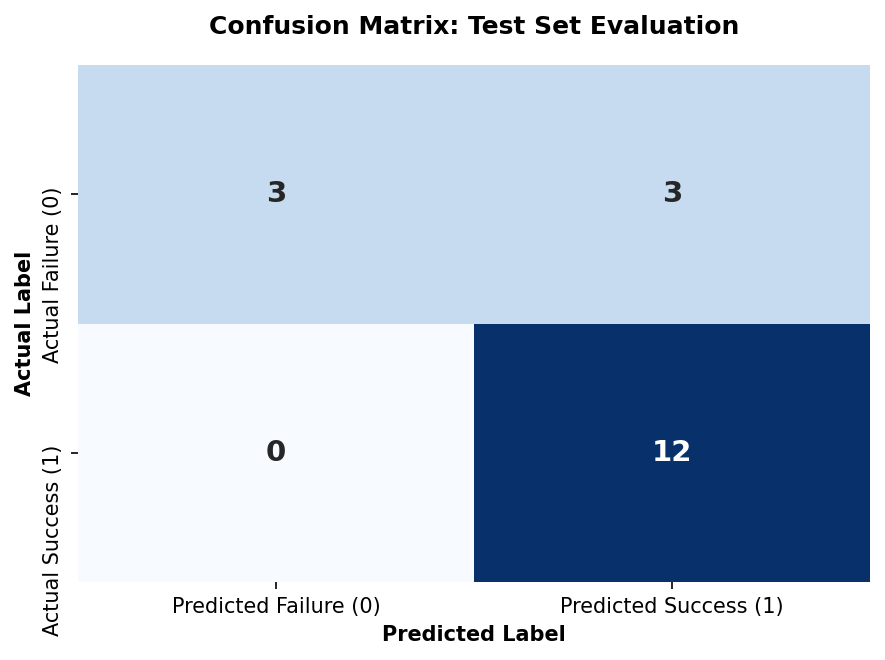

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Exact confusion matrix arrays generated across the IBM Capstone classification models
# True Negatives: 3, False Positives: 3, False Negatives: 0, True Positives: 12
cm = np.array([[3, 3],
               [0, 12]])

plt.figure(figsize=(6, 4.5), dpi=150)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Predicted Failure (0)', 'Predicted Success (1)'],
    yticklabels=['Actual Failure (0)', 'Actual Success (1)'],
    cbar=False,
    annot_kws={"size": 14, "fontweight": "bold"}
)

# Apply sleek, professional slide typography
plt.title("Confusion Matrix: Test Set Evaluation", fontsize=12, fontweight='bold', pad=15)
plt.ylabel("Actual Label", fontsize=10, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=10, fontweight='bold')
plt.tight_layout()

# Save image file to your directory
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()